In [1]:
import h5py
import numpy as np
from h5py.h5r import Reference
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FormatStrFormatter
class Struct:
    def __init__(self, fields):
        for k, v in fields.items():
            setattr(self, k, v)

def load_res(path):
    with h5py.File(path, "r") as f:
        ds = f["res"]
        rec = ds[()]

        fields = {}

        for name in rec.dtype.names:
            field = rec[name]

            if isinstance(field, Reference):      # HDF5 reference
                obj = f[field][()]
                fields[name] = obj
            elif isinstance(field, np.ndarray) and field.shape == ():
                fields[name] = field.item()
            else:
                fields[name] = field

    return Struct(fields)

# Data

In [10]:
L_list = list(range(10, 701, 10))

for L in L_list:
    fname = f"Data/L{L}-SS.jld2"
    res = load_res(fname)

    globals()[f"C_DC_{L}"]          = res.C_DC
    globals()[f"C_DC_err_{L}"]      = res.C_DC_err
    globals()[f"C_DC_std_{L}"] = res. C_DC_std
    globals()[f"C_DC_var_{L}"] = res. C_DC_var
    globals()[f"C_DC_stag_{L}"]     = res.C_DC_stag
    globals()[f"C_DC_stag_std_{L}"] = res. C_DC_stag_std
    globals()[f"C_DC_stag_err_{L}"] = res.C_DC_stag_err

    globals()[f"C_SC_{L}"]          = res.C_SC
    globals()[f"C_SC_err_{L}"]      = res.C_SC_err
    globals()[f"C_SC_std_{L}"]      = res. C_SC_std
    globals()[f"C_SC_var_{L}"]      = res. C_SC_var
    globals()[f"C_SC_stag_{L}"]     = res.C_SC_stag
    globals()[f"C_SC_stag_std_{L}"] = res. C_SC_stag_std
    globals()[f"C_SC_stag_err_{L}"] = res.C_SC_stag_err

    globals()[f"Pbar_{L}"]          = res.Pbar
    globals()[f"Pbar_err_{L}"]      = res.Pbar_err

    globals()[f"mbar0_{L}"]         = res.mbar0
    globals()[f"mbar0_std_{L}"]     = res.mbar0_std

    globals()[f"mbarR_{L}"]         = res.mbarR
    globals()[f"mbarR_err_{L}"]     = res.mbarR_err
    
    globals()[f"G2_{L}"]        = res.G2
    globals()[f"G2_err_{L}"]    = res.G2_err
    globals()[f"G2_abs_{L}"]    = res.G2_abs
    globals()[f"G2_abs_err_{L}"] = res.G2_abs_err

# Fig.6

## Fig.6(a)


==== log SNR = logC + a log L - b log r   ====
n points used: 412
FIT cuts: SNR>=10, L in [40, 500], r in [3, 40], odd_only=True
C = 511.847 ± 15.3325
a = 0.433513 ± 0.005258
b = 2.114047 ± 0.005477
RMSE(logSNR) = 0.063723
R^2(logSNR)  = 0.997277
Saved high-quality PDF as: Figs/SNR_EA_1dMajorana.pdf


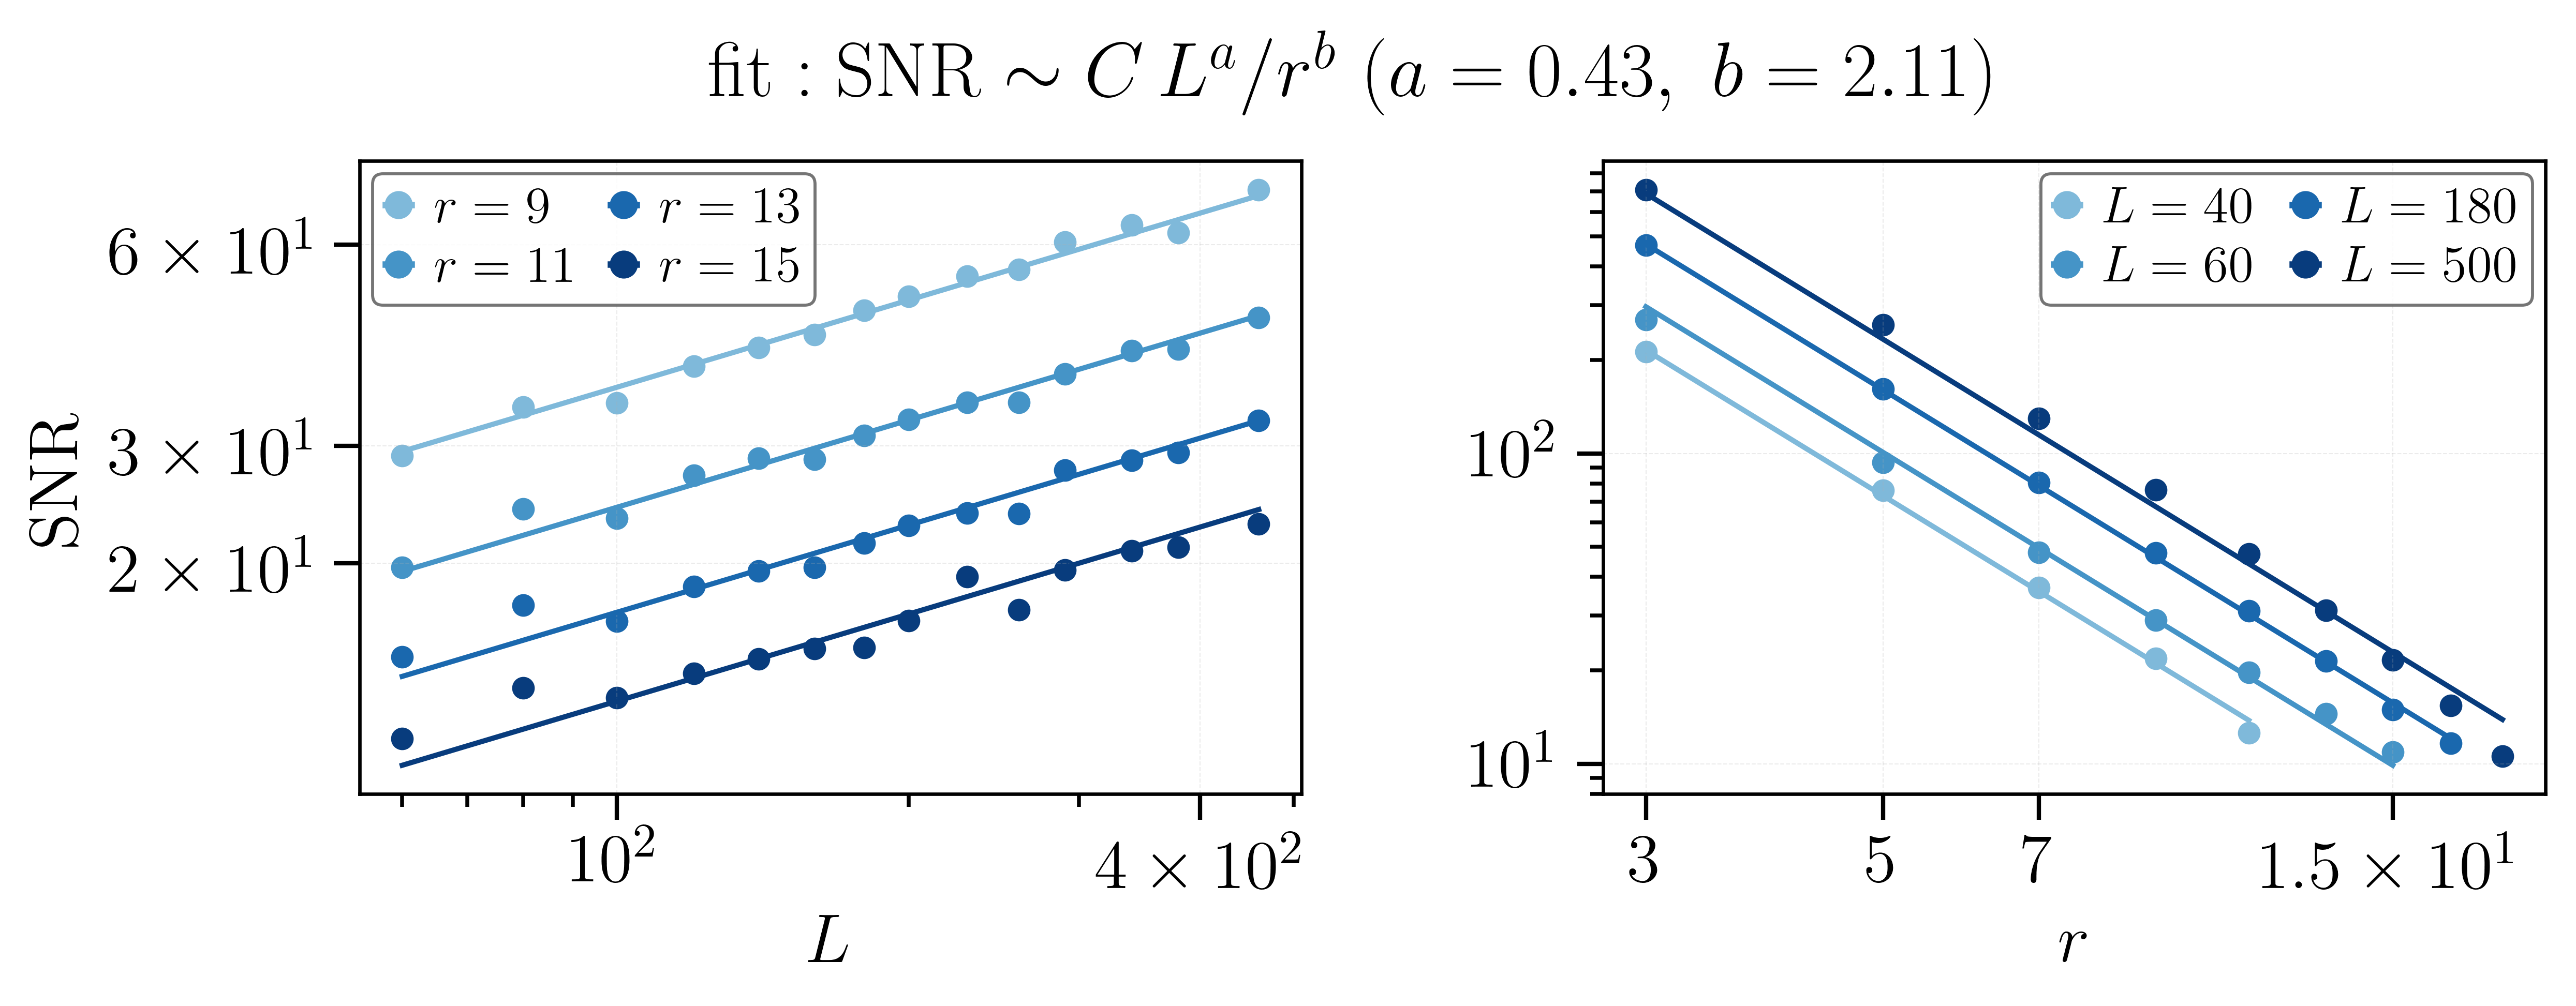

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import (
    FormatStrFormatter, NullLocator, FuncFormatter, NullFormatter
)
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.ticker import FixedLocator, LogLocator
# ---------------------------------------------------------
# Matplotlib / LaTeX settings
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE  = 16
TICK_FSIZE   = 16

# ---------------------------------------------------------
# ---------------------------------------------------------
LEGEND_VALS_FSIZE_1 = 12   # left panel (r legend)
LEGEND_VALS_FSIZE_2 = 12   # right panel (L legend)

# ---------------------------------------------------------
# ---------------------------------------------------------
ROUND_AB = 2


L_list = list(range(40, 701, 10))

# ----------------------------
# FIT CUTS 
# ----------------------------
SNR_MIN_FIT = 10       
FIT_MIN_L   = 40
FIT_MAX_L   = 500
FIT_MIN_R   = 3
FIT_MAX_R   = 40       

# ----------------------------
# ----------------------------
SNR_MIN_PLOT   = 10    
PLOT_MIN_L     = 40
PLOT_MAX_L     = 500
PLOT_MIN_R     = 3
PLOT_MAX_R     = 40
R_MAX_FRAC_PLOT = None   


L_MIN_FIXED_R = 50
L_MAX_FIXED_R = 700


ODD_ONLY = True

R_PLOT = [9, 11, 13, 15]
L_PLOT = [40, 60, 180, 500]

L_SAMPLE_RULES = [
    (200, 20),
    (300, 30),
    (400, 40),
    (600, 60),
    (750, 80),
]

def build_L_list_piecewise(rules, Lmax):
    keep = []
    L0 = 0
    for L1, step in rules:
        keep += list(range(max(step, L0 + step), min(L1, Lmax) + 1, step))
        L0 = L1
    return sorted(set(keep))

L_list_plot_fixed_r = build_L_list_piecewise(L_SAMPLE_RULES, Lmax=max(L_list))


R_SAMPLE_RULES = [
    (800, 1),
]

def build_r_list_piecewise(rules, rmax):
    keep = []
    r0 = 0
    for r1, step in rules:
        r1 = min(r1, rmax)
        start = max(r0 + step, step)
        keep += list(range(start, r1 + 1, step))
        r0 = r1
        if r0 >= rmax:
            break
    return sorted(set(keep))

def keep_only_odd(int_list):
    arr = np.asarray(int_list, dtype=int)
    return arr[(arr % 2) == 1].tolist()

MARKER_S = 18

# ---------------------------------------------------------
# ---------------------------------------------------------
CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Blues

XTICKS_L = None
XTICKS_R = None

# ---------------------------------------------------------
# ---------------------------------------------------------
def style_log_axes(ax, xlabel, ylabel, xticks=None):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3, width=0.9)

def snr_model(L, r, c0, a, b):
    return np.exp(c0) * (L**a) * (r**(-b))

def fit_c0_fixed_r(Ls, sn, r0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(Ls) + b*np.log(float(r0))))

def fit_c0_fixed_L(rs, sn, L0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) + b*np.log(rs)))

def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(map(int, values))
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * np.asarray(ts)
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

def sci_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    exp = int(np.floor(np.log10(x)))
    mant = x / (10.0**exp)
    if exp == 0:
        return rf"${int(round(x))}$"
    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

# =============================================================
# =============================================================
def fit_snr_scaling_L_over_r_from_rows(
    L_vals, r_vals, snr_vals,
    snr_cut=10.0,
    min_r=None, max_r=None,
    min_L=None, max_L=None,
):
    L_vals = np.asarray(L_vals, float)
    r_vals = np.asarray(r_vals, float)
    snr_vals = np.asarray(snr_vals, float)

    mask = np.isfinite(L_vals) & np.isfinite(r_vals) & np.isfinite(snr_vals)
    mask &= (snr_vals > 0)
    if snr_cut is not None:
        mask &= (snr_vals >= float(snr_cut))

    if min_r is not None:
        mask &= (r_vals >= float(min_r))
    if max_r is not None:
        mask &= (r_vals <= float(max_r))
    if min_L is not None:
        mask &= (L_vals >= float(min_L))
    if max_L is not None:
        mask &= (L_vals <= float(max_L))

    L_fit = L_vals[mask]
    r_fit = r_vals[mask]
    snr_fit = snr_vals[mask]

    n = int(snr_fit.size)
    if n < 3:
        raise RuntimeError(f"Not enough points for fit after cuts: n={n}")

    logL = np.log(L_fit)
    logr = np.log(r_fit)
    logs = np.log(snr_fit)

    X = np.column_stack([np.ones_like(logL), logL, -logr])
    beta, residuals, rank, svals = np.linalg.lstsq(X, logs, rcond=None)
    logC, a, b = beta

    logs_hat = X @ beta
    resid = logs - logs_hat

    rmse = float(np.sqrt(np.mean(resid**2)))
    ybar = float(np.mean(logs))
    sse = float(np.sum((logs - logs_hat)**2))
    sst = float(np.sum((logs - ybar)**2))
    r2 = float(1.0 - sse/sst) if sst > 0 else float("nan")

    if residuals.size > 0:
        rss = float(residuals[0])
        dof = max(n - X.shape[1], 1)
        sigma2 = rss / dof
    else:
        sigma2 = float(np.sum(resid**2) / max(n - X.shape[1], 1))

    XtX_inv = np.linalg.inv(X.T @ X)
    cov = sigma2 * XtX_inv
    se_logC = float(np.sqrt(cov[0, 0]))
    se_a    = float(np.sqrt(cov[1, 1]))
    se_b    = float(np.sqrt(cov[2, 2]))

    C = float(np.exp(logC))
    se_C = float(C * se_logC)

    return {
        "C": C, "a": float(a), "b": float(b),
        "sigma_C": se_C, "sigma_a": se_a, "sigma_b": se_b,
        "n_points": n,
        "mask": mask,
        "rmse_logsnr": rmse,
        "r2_logsnr": r2,
        "logC": float(logC),
    }

# =============================================================
# =============================================================
rows_all = []  

for L in L_list:
    y_name = f"C_DC_stag_{L}"
    e_name = f"C_DC_stag_err_{L}"
    if (y_name not in globals()) or (e_name not in globals()):
        continue

    y = np.asarray(globals()[y_name], float)
    e = np.asarray(globals()[e_name], float)
    n_r = int(min(y.size, e.size))
    if n_r <= 0:
        continue

    r_lo = int(max(1, PLOT_MIN_R if PLOT_MIN_R is not None else 1))
    r_hi = int(n_r if PLOT_MAX_R is None else min(n_r, int(PLOT_MAX_R)))
    if FIT_MAX_R is not None:
        r_hi = min(r_hi, int(FIT_MAX_R))  

    if ODD_ONLY:
        if r_lo % 2 == 0:
            r_lo += 1
        step = 2
    else:
        step = 1

    for r in range(r_lo, r_hi + 1, step):
        err = e[r - 1]
        if (not np.isfinite(err)) or err <= 0:
            continue
        snr = np.abs(y[r - 1]) / err
        if (not np.isfinite(snr)) or snr <= 0:
            continue
        rows_all.append((float(L), float(r), float(snr)))

rows_all = np.array(rows_all, dtype=float)
if rows_all.size == 0:
    raise RuntimeError("No points found at all. Check globals() arrays or relax r range.")

# =============================================================
# =============================================================
L_vals = rows_all[:, 0]
r_vals = rows_all[:, 1]
snr_vals = rows_all[:, 2]

res = fit_snr_scaling_L_over_r_from_rows(
    L_vals, r_vals, snr_vals,
    snr_cut=SNR_MIN_FIT,
    min_r=FIT_MIN_R, max_r=FIT_MAX_R,
    min_L=FIT_MIN_L, max_L=FIT_MAX_L,
)

a = float(res["a"])
b = float(res["b"])
C = float(res["C"])
logC = float(res["logC"])

print("\n==== log SNR = logC + a log L - b log r   ====")
print(f"n points used: {res['n_points']}")
print(f"FIT cuts: SNR>={SNR_MIN_FIT}, L in [{FIT_MIN_L}, {FIT_MAX_L}], r in [{FIT_MIN_R}, {FIT_MAX_R}], odd_only={ODD_ONLY}")
print(f"C = {C:.6g} ± {res['sigma_C']:.6g}")
print(f"a = {a:.6f} ± {res['sigma_a']:.6f}")
print(f"b = {b:.6f} ± {res['sigma_b']:.6f}")
print(f"RMSE(logSNR) = {res['rmse_logsnr']:.6f}")
print(f"R^2(logSNR)  = {res['r2_logsnr']:.6f}")

a_leg = round(a, int(ROUND_AB))
b_leg = round(b, int(ROUND_AB))

# =============================================================
# =============================================================
data_by_r = defaultdict(list)  # r -> [(L, snr)]
data_by_L = defaultdict(list)  # L -> [(r, snr)]

for (L, r, snr) in rows_all:
    # plot cuts
    if (SNR_MIN_PLOT is not None) and (snr < float(SNR_MIN_PLOT)):
        continue
    if PLOT_MIN_L is not None and L < float(PLOT_MIN_L):
        continue
    if PLOT_MAX_L is not None and L > float(PLOT_MAX_L):
        continue
    if PLOT_MIN_R is not None and r < float(PLOT_MIN_R):
        continue
    if PLOT_MAX_R is not None and r > float(PLOT_MAX_R):
        continue

    if R_MAX_FRAC_PLOT is not None:
        if r > float(R_MAX_FRAC_PLOT) * L:
            continue
    if ODD_ONLY and (int(round(r)) % 2 == 0):
        continue

    data_by_r[int(round(r))].append((float(L), float(snr)))
    data_by_L[int(round(L))].append((float(r), float(snr)))

# =============================================================
# Plot
# =============================================================
color_by_r = fixed_contrast_color_map(R_PLOT)
color_by_L = fixed_contrast_color_map(L_PLOT)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

# -------------------------
# Left panel: SNR vs L at fixed r
# -------------------------
r_use = [r for r in R_PLOT if int(r) in data_by_r]
if ODD_ONLY:
    r_use = [r for r in r_use if (int(r) % 2 == 1)]
if len(r_use) == 0:
    raise RuntimeError("None of R_PLOT exist after PLOT cuts (and odd-only).")

for r0 in r_use:
    pts = np.array(data_by_r[int(r0)], dtype=float)
    if pts.size == 0:
        continue

    Ls, sn = pts[:, 0], pts[:, 1]

    mask = (Ls >= float(L_MIN_FIXED_R)) & (Ls <= float(L_MAX_FIXED_R))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    mask = np.isin(Ls.astype(int), np.array(L_list_plot_fixed_r, dtype=int))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    order = np.argsort(Ls)
    Ls, sn = Ls[order], sn[order]

    col = color_by_r[int(r0)]

    c0_slice = fit_c0_fixed_r(Ls, sn, r0, a, b)
    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model(L_fit, float(r0), c0_slice, a, b)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax1, xlabel=r"$L$", ylabel=r"$\mathrm{SNR}$", xticks=XTICKS_L)

ax1.set_yticks([20, 30, 60])
ax1.yaxis.set_major_formatter(FuncFormatter(sci_fmt))
ax1.yaxis.set_minor_locator(NullLocator())

# --- Left x-axis: 
ax1.xaxis.set_major_locator(FixedLocator([100.0, 400.0]))
ax1.xaxis.set_major_formatter(FuncFormatter(sci_fmt))

ax1.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)))
ax1.xaxis.set_minor_formatter(NullFormatter())  # ensure no minor labels


ax1.tick_params(axis='x', which='minor', length=3, width=0.9)

# legend
r_handles = []
for r0 in r_use[:4]:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0], [0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))

leg1 = ax1.legend(
    handles=r_handles,
    fontsize=LEGEND_VALS_FSIZE_1,
    loc='upper left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.65,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg1.get_frame().set_edgecolor('0.4')
leg1.get_frame().set_linewidth(0.7)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.9)

# -------------------------
# Right panel: SNR vs r at fixed L
# -------------------------
L_use = [L for L in L_PLOT if int(L) in data_by_L]
if len(L_use) == 0:
    raise RuntimeError("None of L_PLOT exist after PLOT cuts.")

for L0 in L_use:
    pts = np.array(data_by_L[int(L0)], dtype=float)
    if pts.size == 0:
        continue

    rs = np.asarray(pts[:, 0], float)
    sn = np.asarray(pts[:, 1], float)

    if ODD_ONLY:
        odd_mask = (rs.astype(int) % 2 == 1)
        rs, sn = rs[odd_mask], sn[odd_mask]
        if rs.size == 0:
            continue

    order = np.argsort(rs)
    rs, sn = rs[order], sn[order]

    rmax = int(rs.max())
    r_keep = np.array(build_r_list_piecewise(R_SAMPLE_RULES, rmax), dtype=int)
    if ODD_ONLY:
        r_keep = np.array(keep_only_odd(r_keep), dtype=int)

    mask = np.isin(rs.astype(int), r_keep)
    rs_th, sn_th = rs[mask], sn[mask]
    if rs_th.size == 0:
        continue

    col = color_by_L[int(L0)]

    c0_slice = fit_c0_fixed_L(rs, sn, L0, a, b)
    r_fit = np.logspace(np.log10(rs.min()), np.log10(rs.max()), 300)
    sn_fit = snr_model(float(L0), r_fit, c0_slice, a, b)

    ax2.scatter(rs_th, sn_th, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax2, xlabel=r"$r$", ylabel=r"", xticks=XTICKS_R)

ax2.set_xticks([3, 5, 7, 15])
ax2.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
ax2.xaxis.set_minor_locator(NullLocator())

# legend
L_handles = []
for L0 in L_use[:4]:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0], [0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))

leg2 = ax2.legend(
    handles=L_handles,
    fontsize=LEGEND_VALS_FSIZE_2,
    loc='upper right',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.70,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg2.get_frame().set_edgecolor('0.4')
leg2.get_frame().set_linewidth(0.7)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.9)

# -------------------------
# Title + save
# -------------------------
fig.suptitle(
    rf"$\mathrm{{fit}}: \mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}$  ($a={a_leg},\ b={b_leg}$)",
    fontsize=18,
    y=1.02
)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.32)

pdf_name = "Figs/SNR_EA_1dMajorana.pdf"
plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()


## Fig.6(b)


====  log SNR = c0 + a log L - b log r ====
Used points: 722
FIT cuts: L in [40, 500], r in [3, 40], SNR_MIN_FIT=10
c0    =  6.476778 ±  0.093849   (C = exp(c0) = 649.874)
a     =  0.375585 ±  0.016149
b     =  2.093952 ±  0.018171
RMSE(logSNR) = 0.263744
R^2(logSNR)  = 0.948988
Saved high-quality PDF as: Figs/SNR_fm_1dMajorana.pdf


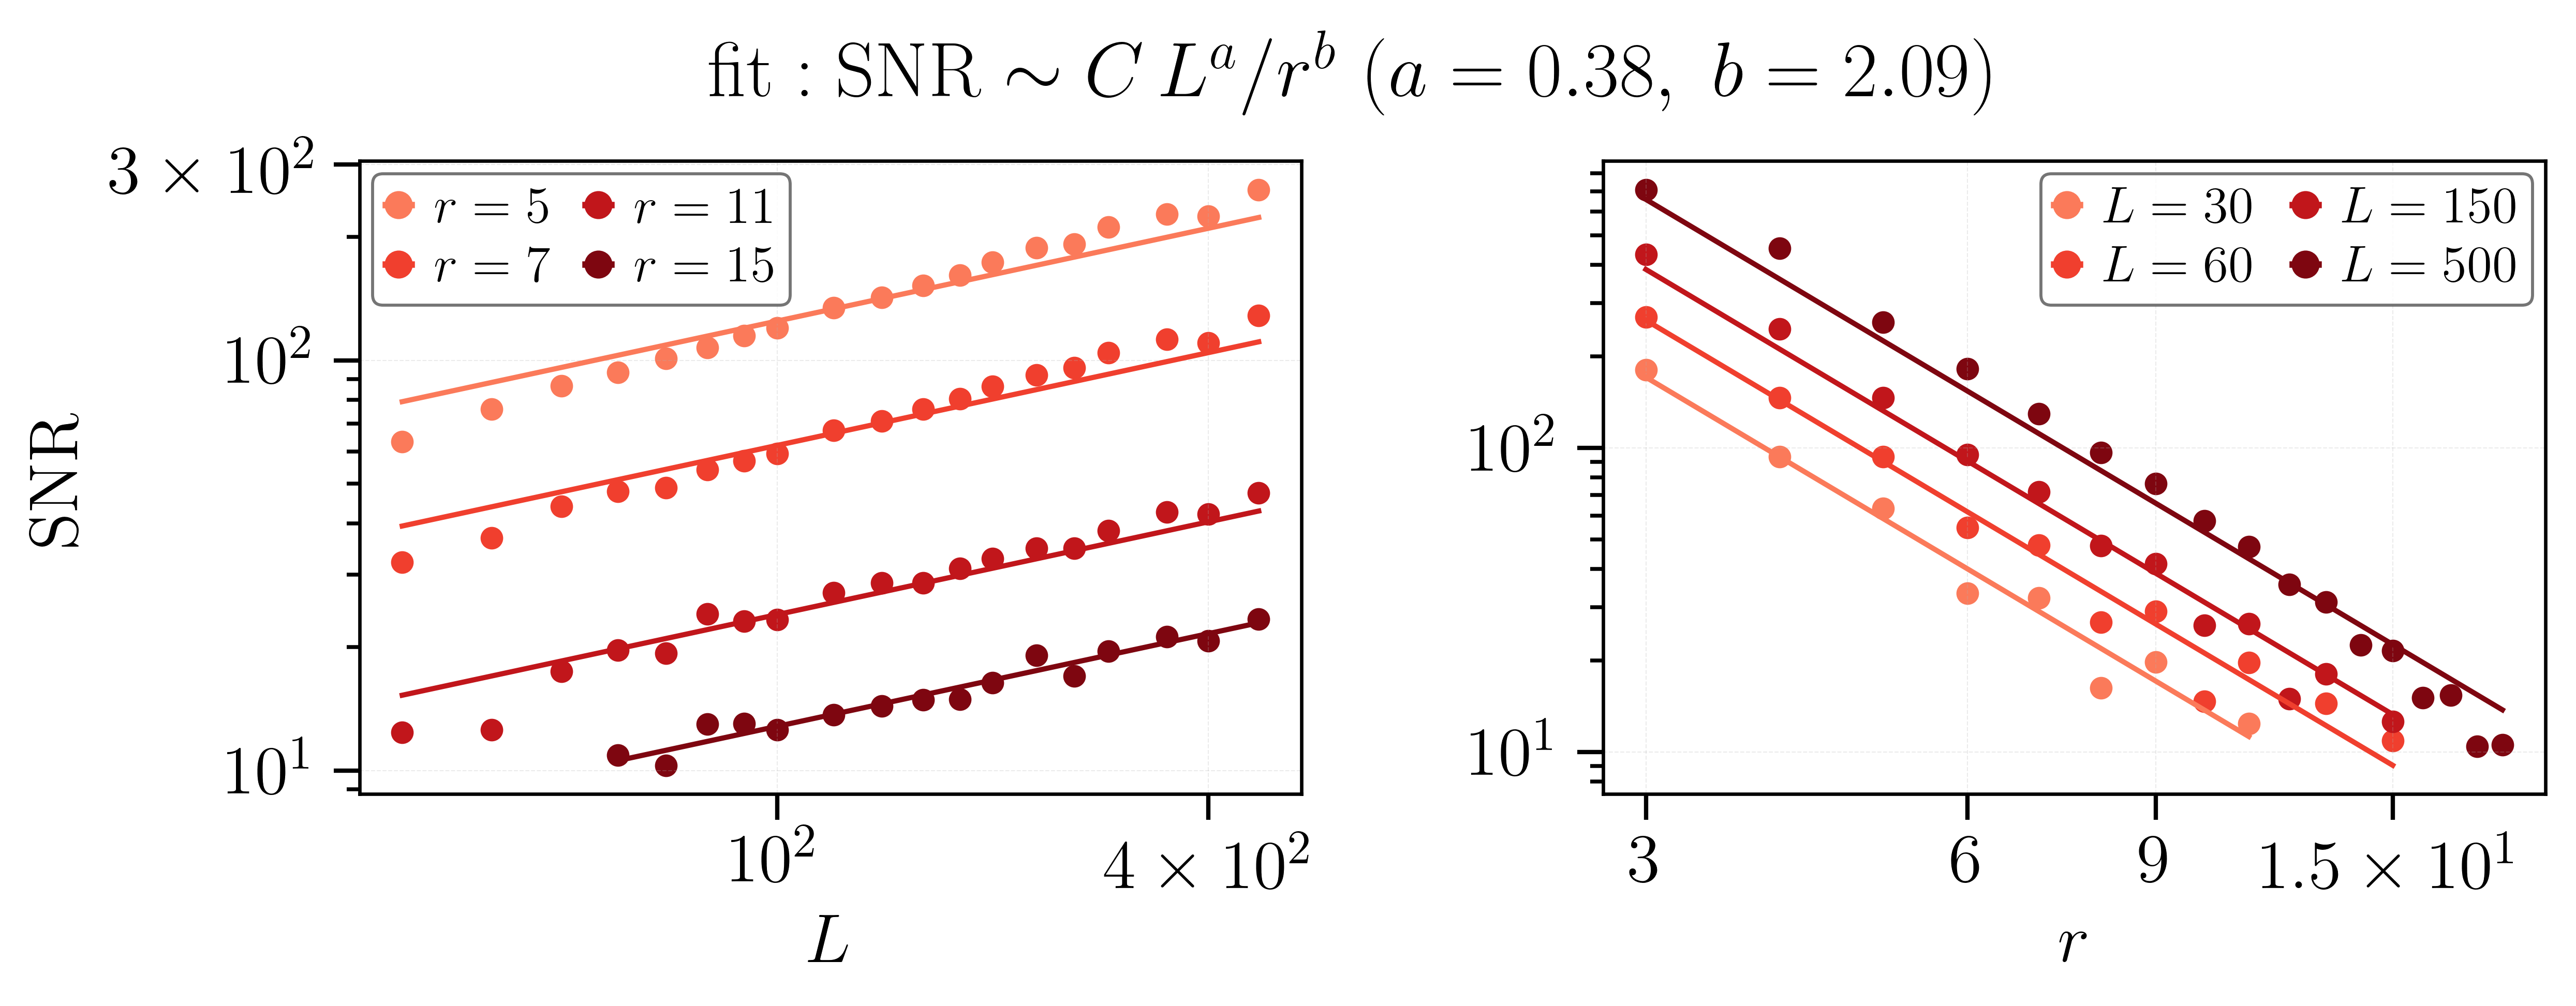

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import (
    FormatStrFormatter, NullLocator, FuncFormatter, NullFormatter, FixedLocator
)
from matplotlib.lines import Line2D
import matplotlib as mpl

# =============================================================
# Matplotlib / LaTeX settings
# =============================================================
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE = 16
TICK_FSIZE  = 16

# =============================================================
# =============================================================
LEGEND_VALS_FSIZE_1 = 12   # left panel (r legend)
LEGEND_VALS_FSIZE_2 = 12   # right panel (L legend)

L_list = list(range(10, 751, 10))

# =============================================================
# =============================================================
SNR_MIN_FIT = 10     
FIT_MIN_L   = 40
FIT_MAX_L   = 500
FIT_MIN_R   = 3
FIT_MAX_R   = 40     


# =============================================================
# =============================================================
SNR_MIN_PLOT = 10   
PLOT_MIN_L   = 30
PLOT_MAX_L   = 500
PLOT_MIN_R   = 3
PLOT_MAX_R   = 20
R_MAX_FRAC_PLOT = None  

L_MIN_FIXED_R = 20


R_PLOT = [5, 7, 11, 15]
L_PLOT = [30, 60, 150, 500]

# --------
L_SAMPLE_RULES = [
    (100, 10),
    (200, 20),
    (300, 30),
    (400, 50),
    (600, 70),
    (800, 80),
    (1000, 90),
]

def build_L_list_piecewise(rules, Lmax=1000):
    keep = []
    L0 = 0
    for L1, step in rules:
        keep += list(range(max(step, L0 + step), min(L1, Lmax) + 1, step))
        L0 = L1
    return sorted(set(keep))

L_list_plot_fixed_r = build_L_list_piecewise(L_SAMPLE_RULES, Lmax=max(L_list))

# --------
R_SAMPLE_RULES = [
    (800, 1),
]

def build_r_list_piecewise(rules, rmax):
    keep = []
    r0 = 0
    for r1, step in rules:
        r1 = min(r1, rmax)
        start = max(r0 + step, step)
        keep += list(range(start, r1 + 1, step))
        r0 = r1
        if r0 >= rmax:
            break
    return sorted(set(keep))

# =============================================================
# =============================================================
MARKER_S = 18
ROUND_AB = 2

CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Reds

XTICKS_L = None
XTICKS_R = None

# =============================================================
# =============================================================
def sci_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    exp = int(np.floor(np.log10(x)))
    mant = x / (10.0**exp)
    mant_r = int(round(mant))

    if exp == 0:
        return rf"${int(round(x))}$"
    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    if np.isclose(mant, mant_r):
        return rf"${mant_r}\times10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

def snr_model(L, r, c0, a, b):
    return np.exp(c0) * (L**a) * (r**(-b))

def fit_c0_fixed_r(Ls, sn, r0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(Ls) + b*np.log(float(r0))))

def fit_c0_fixed_L(rs, sn, L0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) + b*np.log(rs)))

def style_log_axes(ax, xlabel, ylabel, xticks=None):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3, width=0.9)

def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(map(int, values))
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * np.asarray(ts)
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

# =============================================================
# =============================================================
rows_fit = []
for L in L_list:
    y_name = f"C_DC_stag_{L}"
    e_name = f"C_DC_stag_err_{L}"
    if y_name not in globals() or e_name not in globals():
        continue

    y = np.asarray(globals()[y_name], float)
    e = np.asarray(globals()[e_name], float)
    n_r = int(min(len(y), len(e)))
    if n_r <= 0:
        continue

    r_lo = int(max(1, FIT_MIN_R if FIT_MIN_R is not None else 1))
    r_hi = int(n_r if FIT_MAX_R is None else min(n_r, int(FIT_MAX_R)))

    if FIT_MIN_L is not None and L < float(FIT_MIN_L):
        continue
    if FIT_MAX_L is not None and L > float(FIT_MAX_L):
        continue

    for r in range(r_lo, r_hi + 1):
        err = e[r - 1]
        if (not np.isfinite(err)) or err <= 0:
            continue
        snr = np.abs(y[r - 1]) / err
        if (not np.isfinite(snr)) or snr <= 0:
            continue
        if (SNR_MIN_FIT is not None) and (snr < float(SNR_MIN_FIT)):
            continue

        rows_fit.append((float(L), float(r), float(snr)))

rows_fit = np.array(rows_fit, dtype=float)
if rows_fit.size == 0:
    raise RuntimeError("No FIT data survived cuts. Relax SNR_MIN_FIT / FIT_MAX_R / FIT_MIN_L, or check globals().")

L_fit_vals, r_fit_vals, snr_fit_vals = rows_fit[:, 0], rows_fit[:, 1], rows_fit[:, 2]
logL, logr, logSNR = np.log(L_fit_vals), np.log(r_fit_vals), np.log(snr_fit_vals)

X = np.column_stack([np.ones_like(logL), logL, logr])
beta, residuals, rank, svals = np.linalg.lstsq(X, logSNR, rcond=None)
c0, a, c_r = beta
b = -c_r

yhat = X @ beta
resid = logSNR - yhat

n, p = X.shape
dof = max(n - p, 1)
sigma2 = float(np.sum(resid**2) / dof)
cov = sigma2 * np.linalg.inv(X.T @ X)
se = np.sqrt(np.diag(cov))
c0_se, a_se, c_r_se = map(float, se)
b_se = float(c_r_se)

rmse = float(np.sqrt(np.mean(resid**2)))
ybar = float(np.mean(logSNR))
ss_res = float(np.sum((logSNR - yhat)**2))
ss_tot = float(np.sum((logSNR - ybar)**2))
r2 = float(1.0 - ss_res/ss_tot) if ss_tot > 0 else float("nan")

a_leg = round(float(a), int(ROUND_AB))
b_leg = round(float(b), int(ROUND_AB))

print("\n====  log SNR = c0 + a log L - b log r ====")
print(f"Used points: {len(logSNR)}")
print(f"FIT cuts: L in [{FIT_MIN_L}, {FIT_MAX_L}], r in [{FIT_MIN_R}, {FIT_MAX_R}], SNR_MIN_FIT={SNR_MIN_FIT}")
print(f"c0    = {c0: .6f} ± {c0_se: .6f}   (C = exp(c0) = {np.exp(c0):.6g})")
print(f"a     = {a: .6f} ± {a_se: .6f}")
print(f"b     = {b: .6f} ± {b_se: .6f}")
print(f"RMSE(logSNR) = {rmse:.6f}")
print(f"R^2(logSNR)  = {r2:.6f}")

# =============================================================
# =============================================================
data_by_r = defaultdict(list)  # r -> [(L, snr)]
data_by_L = defaultdict(list)  # L -> [(r, snr)]

for L in L_list:
    y_name = f"C_DC_stag_{L}"
    e_name = f"C_DC_stag_err_{L}"
    if y_name not in globals() or e_name not in globals():
        continue

    # plot L cuts
    if PLOT_MIN_L is not None and L < float(PLOT_MIN_L):
        continue
    if PLOT_MAX_L is not None and L > float(PLOT_MAX_L):
        continue

    y = np.asarray(globals()[y_name], float)
    e = np.asarray(globals()[e_name], float)
    n_r = int(min(len(y), len(e)))
    if n_r <= 0:
        continue


    r_lo = int(max(1, PLOT_MIN_R if PLOT_MIN_R is not None else 1))
    r_hi = int(n_r if PLOT_MAX_R is None else min(n_r, int(PLOT_MAX_R)))

    if R_MAX_FRAC_PLOT is not None:
        r_hi = min(r_hi, int(np.floor(float(R_MAX_FRAC_PLOT) * float(L))))

    for r in range(r_lo, r_hi + 1):
        err = e[r - 1]
        if (not np.isfinite(err)) or err <= 0:
            continue
        snr = np.abs(y[r - 1]) / err
        if (not np.isfinite(snr)) or snr <= 0:
            continue
        if (SNR_MIN_PLOT is not None) and (snr < float(SNR_MIN_PLOT)):
            continue

        data_by_r[int(r)].append((float(L), float(snr)))
        data_by_L[int(L)].append((float(r), float(snr)))

# =============================================================
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

color_by_r = fixed_contrast_color_map(R_PLOT)
color_by_L = fixed_contrast_color_map(L_PLOT)

# -------------------------
# Left panel: SNR vs L at fixed r
# -------------------------
r_use = [r for r in R_PLOT if int(r) in data_by_r]
if len(r_use) == 0:
    raise RuntimeError("None of R_PLOT exist after PLOT cuts. Relax PLOT cuts or change R_PLOT.")

for r0 in r_use:
    pts = np.array(data_by_r[int(r0)], dtype=float)
    if pts.size == 0:
        continue

    Ls, sn = pts[:, 0], pts[:, 1]

    mask = (Ls >= float(L_MIN_FIXED_R))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    mask = np.isin(Ls.astype(int), np.array(L_list_plot_fixed_r, dtype=int))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    order = np.argsort(Ls)
    Ls, sn = Ls[order], sn[order]

    col = color_by_r[int(r0)]

    c0_slice = fit_c0_fixed_r(Ls, sn, r0, a, b)
    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model(L_fit, float(r0), c0_slice, a, b)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax1, xlabel=r"$L$", ylabel=r"$\mathrm{SNR}$", xticks=XTICKS_L)

yt = [t for t in ax1.get_yticks() if t > 0 and np.isfinite(t)]
yt = sorted(set(yt + [300.0]))
ax1.yaxis.set_major_locator(FixedLocator(yt))
ax1.yaxis.set_major_formatter(FuncFormatter(sci_fmt))
ax1.yaxis.set_minor_formatter(NullFormatter())


ax1.xaxis.set_major_locator(FixedLocator([100, 400]))
ax1.xaxis.set_major_formatter(FuncFormatter(sci_fmt))


ax1.xaxis.set_minor_locator(NullLocator())
# Left legend: r values
r_handles = []
for r0 in r_use[:4]:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0], [0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))

leg1 = ax1.legend(
    handles=r_handles,
    fontsize=LEGEND_VALS_FSIZE_1,
    loc='upper left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.65,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg1.get_frame().set_edgecolor('0.4')
leg1.get_frame().set_linewidth(0.7)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.9)

# -------------------------
# Right panel: SNR vs r at fixed L
# -------------------------
L_use = [L for L in L_PLOT if int(L) in data_by_L]
if len(L_use) == 0:
    raise RuntimeError("None of L_PLOT exist after PLOT cuts. Relax PLOT cuts or change L_PLOT.")

for L0 in L_use:
    pts = np.array(data_by_L[int(L0)], dtype=float)
    if pts.size == 0:
        continue

    rs = np.asarray(pts[:, 0], float)
    sn = np.asarray(pts[:, 1], float)

    order = np.argsort(rs)
    rs, sn = rs[order], sn[order]

    rmax = int(np.max(rs))
    r_keep = np.array(build_r_list_piecewise(R_SAMPLE_RULES, rmax), dtype=int)
    mask = np.isin(rs.astype(int), r_keep)
    rs_th, sn_th = rs[mask], sn[mask]
    if rs_th.size == 0:
        continue

    col = color_by_L[int(L0)]

    c0_slice = fit_c0_fixed_L(rs_th, sn_th, L0, a, b)
    r_fit = np.logspace(np.log10(rs_th.min()), np.log10(rs_th.max()), 300)
    sn_fit = snr_model(float(L0), r_fit, c0_slice, a, b)

    ax2.scatter(rs_th, sn_th, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax2, xlabel=r"$r$", ylabel=r"", xticks=XTICKS_R)

ax2.set_xticks([3, 6, 9, 15])
ax2.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
ax2.xaxis.set_minor_locator(NullLocator())


L_handles = []
for L0 in L_use[:4]:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0], [0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))

leg2 = ax2.legend(
    handles=L_handles,
    fontsize=LEGEND_VALS_FSIZE_2,
    loc='upper right',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.70,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg2.get_frame().set_edgecolor('0.4')
leg2.get_frame().set_linewidth(0.7)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.9)

# -------------------------
# Title + layout + save
# -------------------------
fig.suptitle(
    rf"$\mathrm{{fit}}: \mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}$  ($a={a_leg},\ b={b_leg}$)",
    fontsize=18,
    y=1.02
)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.32)

pdf_name = "Figs/SNR_fm_1dMajorana.pdf"
plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()


## Fig.6(c)


 log SNR = c0 + a log L - b log r ====
Used points: 1777   (cuts: 40 <= L <= 500, 3 <= r <= 40, SNR_MIN=10)
c0    =  4.842959 ±  0.020012   (C = exp(c0) = 126.844)
a     =  0.566192 ±  0.003285
b     =  1.108202 ±  0.003147
RMSE(logSNR) = 0.089295
R^2(logSNR)  = 0.988466
Saved high-quality PDF as: Figs/SNR_sc_1dMajorana.pdf


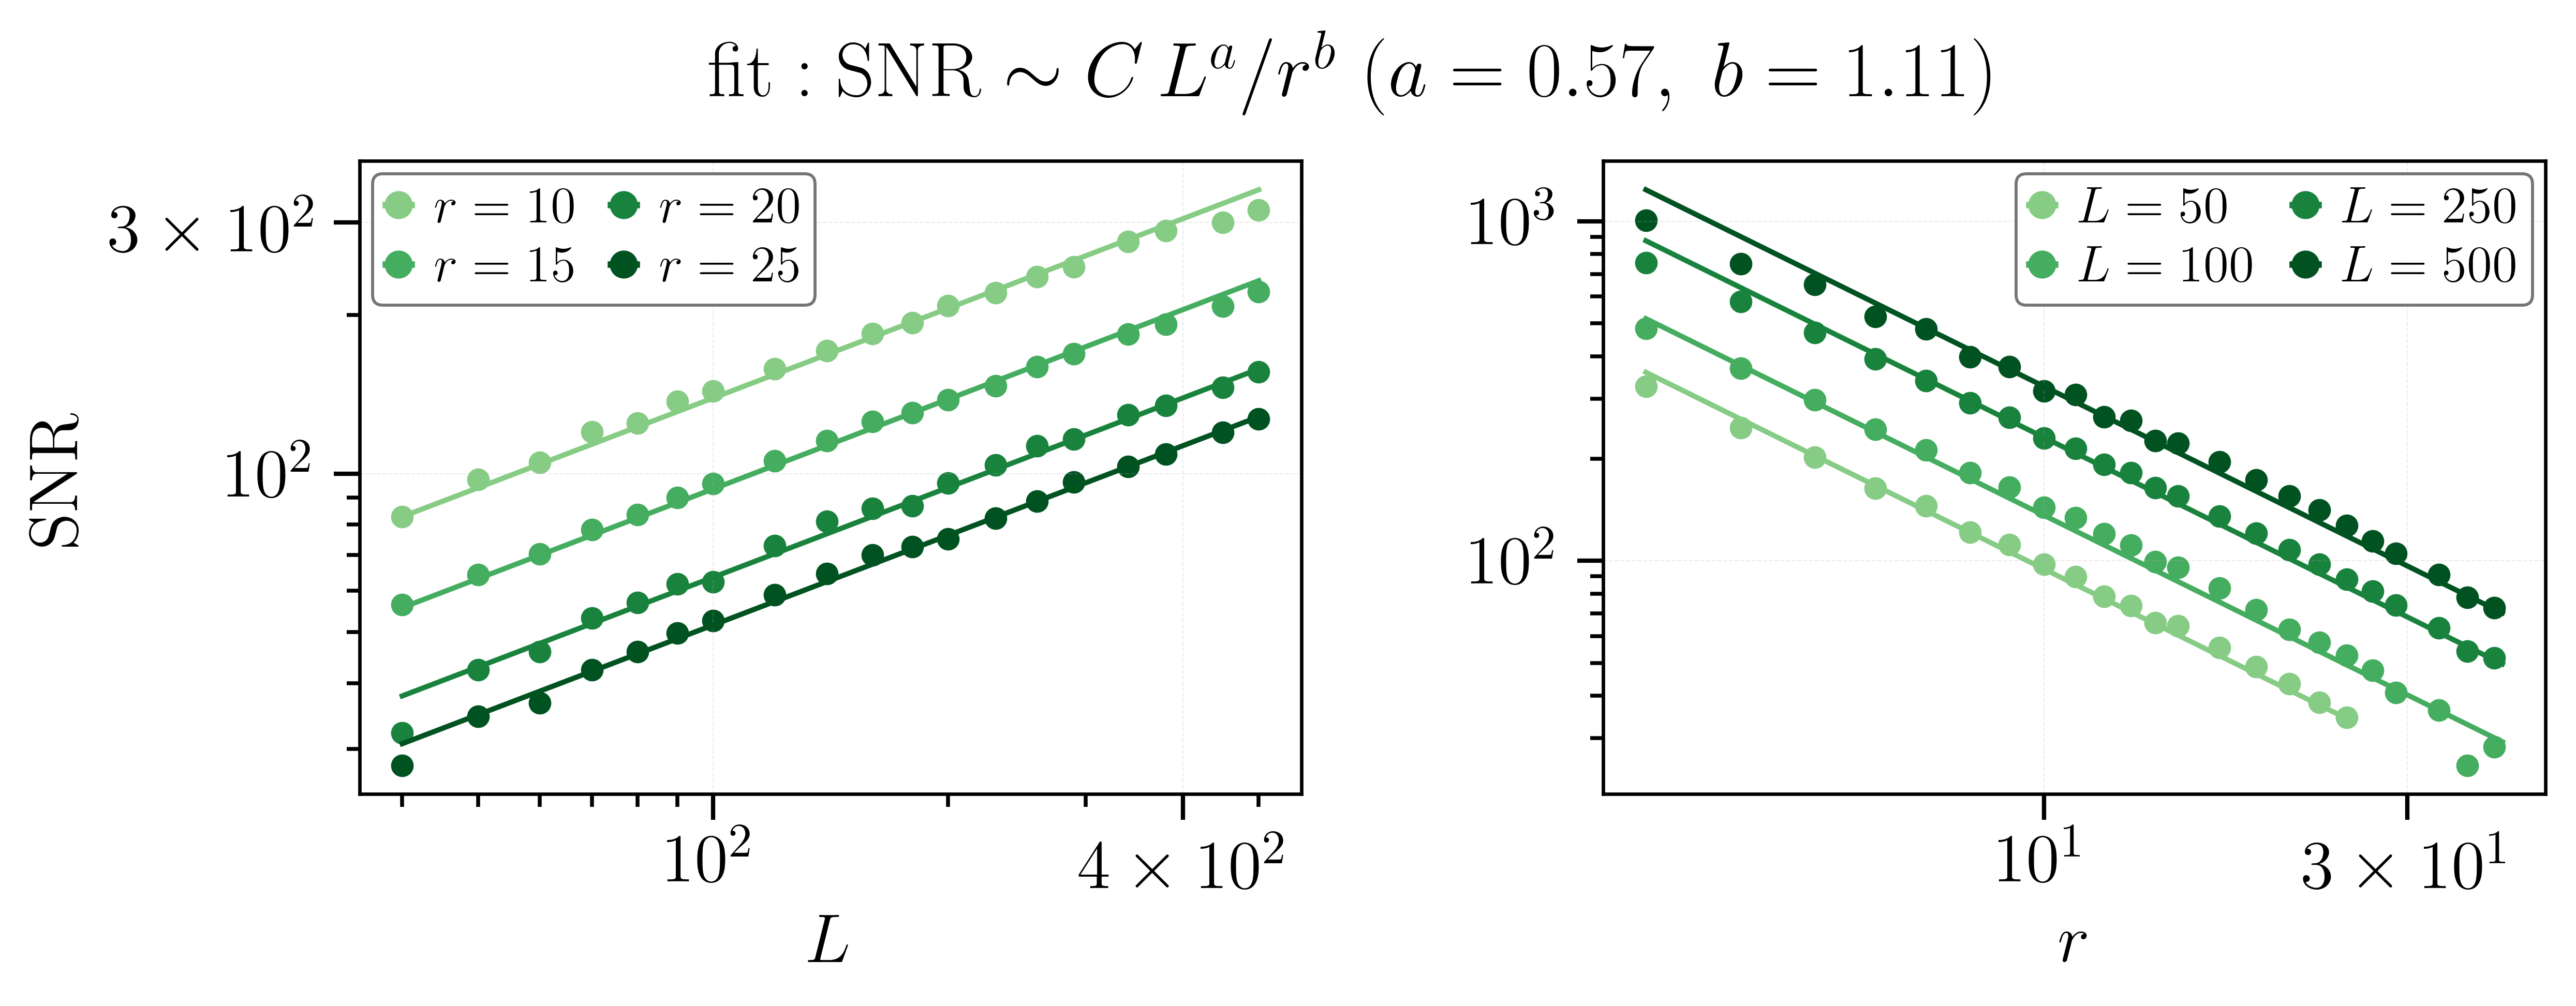

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import (
    FormatStrFormatter, NullLocator, FuncFormatter, NullFormatter, FixedLocator
)
from matplotlib.lines import Line2D
import matplotlib as mpl

# ---------------------------------------------------------
# Matplotlib / LaTeX settings
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16

# ---------------------------------------------------------
# ---------------------------------------------------------
ROUND_AB = 2

# ---------------------------------------------------------
# ---------------------------------------------------------
R_MIN         = 3
R_MAX_FIT     = 40       
SNR_MIN       = 10        

L_MIN_FIT     = 40
L_MAX_FIT     = 500


USE_PLOT_R_OVER_L_CUT = True
R_MAX_FRAC_PLOT       = 0.5    

L_MAX_PLOT = 500


R_PLOT = [10, 15, 20, 25]
L_PLOT = [50, 100, 250, 500]


L_list_fit  = list(range(10, 751, 10))


L_SAMPLE_RULES = [
    (100, 10),
    (200, 20),
    (300, 30),
    (400, 40),
    (500, 50),
    (600, 60),
    (1000, 80),
]

def build_L_list_piecewise(rules, Lmax=1000):
    keep = []
    L0 = 0
    for L1, step in rules:
        keep += list(range(max(step, L0 + step), min(L1, Lmax) + 1, step))
        L0 = L1
    return sorted(set(keep))

L_list_plot_fixed_r = build_L_list_piecewise(L_SAMPLE_RULES, Lmax=L_MAX_PLOT)

MARKER_S = 18


R_SAMPLE_RULES = [
    (15,  1),
    (30,  2),
    (80,  3),
    (100,  6),
    (120, 7)
]

def build_r_list_piecewise(rules, rmax):
    keep = []
    r0 = 0
    for r1, step in rules:
        r1 = min(r1, rmax)
        start = max(r0 + step, step)
        keep += list(range(start, r1 + 1, step))
        r0 = r1
        if r0 >= rmax:
            break
    return sorted(set(keep))

# ---------------------------------------------------------
# ---------------------------------------------------------
CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Greens

XTICKS_L = None
XTICKS_R = None

def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(map(int, values))
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * ts
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

color_by_r = fixed_contrast_color_map(R_PLOT)
color_by_L = fixed_contrast_color_map(L_PLOT)

# ---------------------------------------------------------
# ---------------------------------------------------------
def sci_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    exp = int(np.floor(np.log10(x)))
    mant = x / (10.0**exp)
    mant_r = int(round(mant))

    if exp == 0:
        return rf"${int(round(x))}$"
    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    if np.isclose(mant, mant_r):
        return rf"${mant_r}\times10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

def style_log_axes(ax, xlabel, ylabel, xticks=None):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3, width=0.9)

# ---------------------------------------------------------
# ---------------------------------------------------------
def snr_model(L, r, c0, a, b):
    return np.exp(c0) * (L**a) * (r**(-b))

def fit_c0_fixed_r(Ls, sn, r0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(Ls) + b*np.log(float(r0))))

def fit_c0_fixed_L(rs, sn, L0, a, b):
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) + b*np.log(rs)))

# ---------------------------------------------------------
# ---------------------------------------------------------
rows = []
data_by_r = defaultdict(list)  # r -> [(L, snr)]
data_by_L = defaultdict(list)  # L -> [(r, snr)]

for L in L_list_fit:
    if not (L_MIN_FIT <= L <= L_MAX_FIT):
        continue

    y_name = f"C_SC_stag_{L}"
    e_name = f"C_SC_stag_err_{L}"
    if y_name not in globals() or e_name not in globals():
        continue

    y = np.asarray(globals()[y_name], dtype=float)
    e = np.asarray(globals()[e_name], dtype=float)
    n_r = min(len(y), len(e))

    r_max_fit_here = min(n_r, int(R_MAX_FIT))

    for r in range(int(R_MIN), r_max_fit_here + 1):
        err = e[r - 1]
        if not np.isfinite(err) or err <= 0:
            continue

        snr = np.abs(y[r - 1]) / err
        if not np.isfinite(snr) or snr <= 0:
            continue

        if (SNR_MIN is not None) and (snr < float(SNR_MIN)):
            continue

        rows.append((L, r, snr))
        data_by_r[r].append((L, snr))
        data_by_L[L].append((r, snr))

rows = np.array(rows, dtype=float)
if rows.size == 0:
    raise RuntimeError("No data survived FIT cuts. Relax SNR_MIN / L window / R_MAX_FIT or check inputs.")

L_vals, r_vals, snr_vals = rows[:, 0], rows[:, 1], rows[:, 2]
logL, logr, logSNR = np.log(L_vals), np.log(r_vals), np.log(snr_vals)

# ---------------------------------------------------------
# ---------------------------------------------------------
X = np.column_stack([np.ones_like(logL), logL, logr])
beta, residuals, rank, s = np.linalg.lstsq(X, logSNR, rcond=None)
c0, a, c_r = beta
b = -c_r

yhat = X @ beta
resid = logSNR - yhat
n, p = X.shape
dof = max(n - p, 1)
sigma2 = np.sum(resid**2) / dof
cov = sigma2 * np.linalg.inv(X.T @ X)
se = np.sqrt(np.diag(cov))
c0_se, a_se, c_r_se = se
b_se = c_r_se

rmse = float(np.sqrt(np.mean(resid**2)))
ybar = np.mean(logSNR)
ss_res = np.sum((logSNR - yhat)**2)
ss_tot = np.sum((logSNR - ybar)**2)
r2 = float(1.0 - ss_res/ss_tot) if ss_tot > 0 else np.nan

a_leg = round(float(a), int(ROUND_AB))
b_leg = round(float(b), int(ROUND_AB))

print("\n log SNR = c0 + a log L - b log r ====")
print(
    f"Used points: {len(logSNR)}   "
    f"(cuts: {L_MIN_FIT} <= L <= {L_MAX_FIT}, {R_MIN} <= r <= {R_MAX_FIT}, SNR_MIN={SNR_MIN})"
)
print(f"c0    = {c0: .6f} ± {c0_se: .6f}   (C = exp(c0) = {np.exp(c0):.6g})")
print(f"a     = {a: .6f} ± {a_se: .6f}")
print(f"b     = {b: .6f} ± {b_se: .6f}")
print(f"RMSE(logSNR) = {rmse:.6f}")
print(f"R^2(logSNR)  = {r2:.6f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

r_use = [r for r in R_PLOT if int(r) in data_by_r]
if len(r_use) == 0:
    raise RuntimeError("None of R_PLOT exist after FIT cuts. Increase R_MAX_FIT or relax SNR_MIN.")

for r0 in r_use:
    pts = np.array(data_by_r[int(r0)], dtype=float)
    if pts.size == 0:
        continue

    Ls, sn = pts[:, 0], pts[:, 1]

    keep = (Ls <= float(L_MAX_PLOT))
    Ls, sn = Ls[keep], sn[keep]

    mask = np.isin(Ls.astype(int), np.array(L_list_plot_fixed_r, dtype=int))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    order = np.argsort(Ls)
    Ls, sn = Ls[order], sn[order]

    col = color_by_r[int(r0)]

    c0_slice = fit_c0_fixed_r(Ls, sn, r0, a, b)
    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model(L_fit, r0, c0_slice, a, b)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, linestyle='-', color=col, lw=1.2)

style_log_axes(ax1, xlabel=r"$L$", ylabel=r"$\mathrm{SNR}$", xticks=XTICKS_L)

yt = [t for t in ax1.get_yticks() if t > 0]
yt = sorted(set(yt + [300.0]))
ax1.yaxis.set_major_locator(FixedLocator(yt))
ax1.yaxis.set_major_formatter(FuncFormatter(sci_fmt))
ax1.yaxis.set_minor_formatter(NullFormatter())

r_handles = []
for r0 in r_use[:4]:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))

leg1 = ax1.legend(
    handles=r_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.65,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
frame = leg1.get_frame()
frame.set_edgecolor('0.4')
frame.set_linewidth(0.7)
frame.set_facecolor('white')
frame.set_alpha(0.9)

# =============================================================
# =============================================================
L_use = [L for L in L_PLOT if int(L) in data_by_L]
if len(L_use) == 0:
    raise RuntimeError("None of L_PLOT exist after FIT cuts. Relax L_MIN_FIT or SNR_MIN.")

for L0 in L_use:
    pts = np.array(data_by_L[int(L0)], dtype=float)
    if pts.size == 0:
        continue

    rs = np.asarray(pts[:, 0], float)
    sn = np.asarray(pts[:, 1], float)

    # Optional plot-only r/L cut
    if USE_PLOT_R_OVER_L_CUT:
        rs_max_plot = float(R_MAX_FRAC_PLOT) * float(L0)
        keep = (rs <= rs_max_plot)
        rs, sn = rs[keep], sn[keep]

    order = np.argsort(rs)
    rs, sn = rs[order], sn[order]
    if rs.size == 0:
        continue

    rmax = int(rs.max())
    r_keep = np.array(build_r_list_piecewise(R_SAMPLE_RULES, rmax), dtype=int)
    mask = np.isin(rs.astype(int), r_keep)
    rs_th, sn_th = rs[mask], sn[mask]
    if rs_th.size == 0:
        continue

    col = color_by_L[int(L0)]

    c0_slice = fit_c0_fixed_L(rs, sn, L0, a, b)
    r_fit = np.logspace(np.log10(rs.min()), np.log10(rs.max()), 300)
    sn_fit = snr_model(L0, r_fit, c0_slice, a, b)

    ax2.scatter(rs_th, sn_th, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, linestyle='-', color=col, lw=1.2)

style_log_axes(ax2, xlabel=r"$r$", ylabel="", xticks=XTICKS_R)
from matplotlib.ticker import FixedLocator

ax2.xaxis.set_major_locator(FixedLocator([10, 30]))
ax2.xaxis.set_major_formatter(FuncFormatter(sci_fmt))

ax2.xaxis.set_minor_locator(NullLocator())


ax1.xaxis.set_major_locator(FixedLocator([100, 400]))
ax1.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
L_handles = []
for L0 in L_use[:4]:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))

leg2 = ax2.legend(
    handles=L_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper right',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.70,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
frame = leg2.get_frame()
frame.set_edgecolor('0.4')
frame.set_linewidth(0.7)
frame.set_facecolor('white')
frame.set_alpha(0.9)

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------
fig.suptitle(
    rf"$\mathrm{{fit}}: \mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}$  ($a={a_leg},\ b={b_leg}$)",
    fontsize=18,
    y=1.02
)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.32)

pdf_name = "Figs/SNR_sc_1dMajorana.pdf"
plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()